In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import joblib

In [2]:
df = pd.read_csv('../../../data/preprocessed/selected_features_dataset.csv')

In [3]:
X = df.drop(['price_per_m2'], axis=1)
y = df['price_per_m2']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
X_train_main, X_val, y_train_main, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [6]:
def add_noise(X, noise_level=0.01):
    """Add Gaussian noise to numerical features."""
    X_noisy = X.copy()
    # Apply noise only to numeric columns
    numeric_cols = X_noisy.select_dtypes(include=np.number).columns
    noise = np.random.normal(0, noise_level, X_noisy[numeric_cols].shape)
    X_noisy.loc[:, numeric_cols] += noise
    return X_noisy

In [7]:
noise_level = 0.01

In [8]:
X_train_main_noisy = add_noise(X_train_main, noise_level=noise_level)

In [9]:
params = {
    'objective': 'reg:absoluteerror',
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'n_estimators': 150,
    'early_stopping_rounds': 50,
    'eval_metric': 'mae',
    'learning_rate': 0.07,
    'max_depth': 5,
    'min_child_weight': 10,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'gamma': 0.4,
    'reg_alpha': 1.8,
    'reg_lambda': 0.1
}

In [10]:
model = XGBRegressor(**params)

In [11]:
model.fit(
    X_train_main_noisy, y_train_main,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-mae:1281.24682
[100]	validation_0-mae:353.59873
[149]	validation_0-mae:350.20511


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=0.4, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.07, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=-1, num_parallel_tree=None, ...)

In [12]:
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

[0]	validation_0-mae:1278.20455
[100]	validation_0-mae:314.01765
[149]	validation_0-mae:295.94110


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='mae', feature_types=None,
             feature_weights=None, gamma=0.4, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.07, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=150,
             n_jobs=-1, num_parallel_tree=None, ...)

In [13]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [14]:
def print_metrics(y_true, y_pred, set_name):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100

    print(f"\n{set_name} Metrics:")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    if set_name == "Test":
        print(f"Avg Price: {y_true.mean():.2f}")
    return mae

In [15]:
train_mae = print_metrics(y_train, y_pred_train, "Train")
test_mae = print_metrics(y_test, y_pred_test, "Test")


Train Metrics:
R²: 0.9127
MAE: 304.80
MAPE: 33.04%

Test Metrics:
R²: 0.8897
MAE: 353.71
MAPE: 37.00%
Avg Price: 1664.70


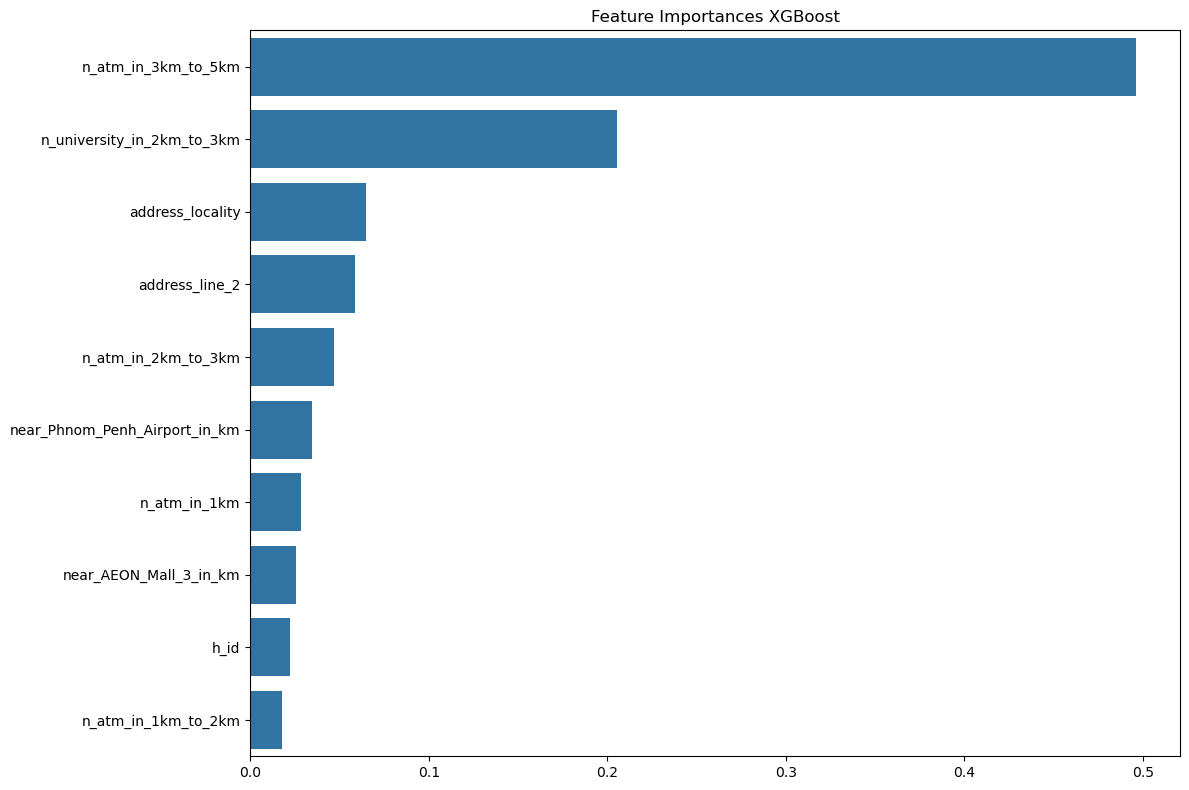

In [25]:
feature_importance = model.feature_importances_
sorted_idx = np.argsort(feature_importance)[::-1]
sorted_features = [X.columns[i] for i in sorted_idx]

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance[sorted_idx][:10], y=sorted_features[:10])
plt.title('Feature Importances XGBoost')
plt.tight_layout()
plt.show()

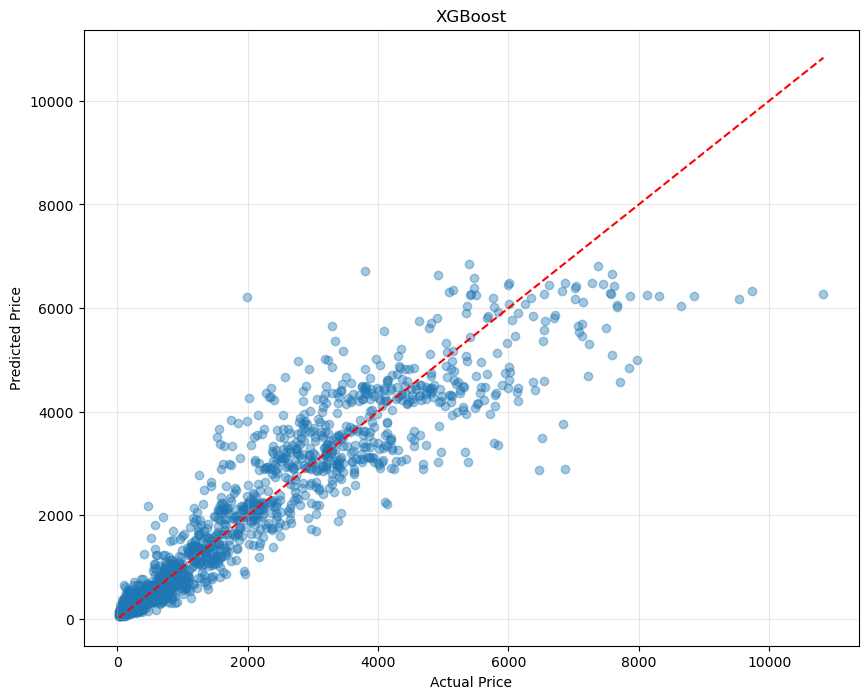

In [22]:
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost")
plt.grid(alpha=0.3)
plt.show()

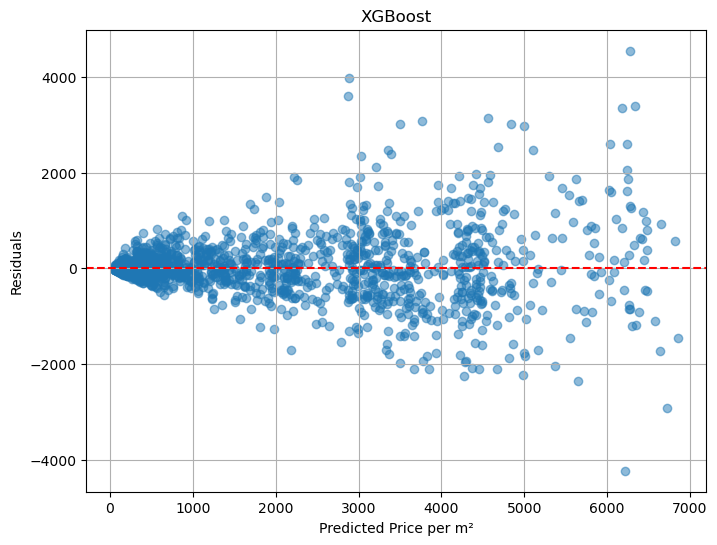

In [24]:
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price per m²")
plt.ylabel("Residuals")
plt.title("XGBoost")
plt.grid(True)
plt.show()

In [18]:
def calculate_metrics(model, X_train, y_train, X_test, y_test):
    # Train set predictions
    y_pred_train = model.predict(X_train)
    
    # Test set predictions
    y_pred_test = model.predict(X_test)
    
    # Calculate metrics for test set
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mape = np.mean(np.abs((y_test - y_pred_test) / np.maximum(y_test, 1))) * 100
    
    # Calculate train R2
    train_r2 = r2_score(y_train, y_pred_train)
    
    # Create metrics dataframe
    metrics_df = pd.DataFrame({
        'Metric': ['R2(Test)', 'MAE', 'RMSE', 'MAPE', 'Train R2'],
        'Value': [test_r2, test_mae, test_rmse, test_mape, train_r2]
    })
    
    return metrics_df.round(4)

In [19]:
metrics_df = calculate_metrics(model, X_train, y_train, X_test, y_test)
print("\nModel Performance Metrics:")
print("="*50)
print(metrics_df.to_string(index=False))
print("="*50)


Model Performance Metrics:
  Metric    Value
R2(Test)   0.8897
     MAE 353.7101
    RMSE 614.2986
    MAPE  37.0042
Train R2   0.9127


In [20]:
joblib.dump(model, "../../../models/xgboost/xgboost_model_v5_label.joblib")

['../../../models/xgboost/xgboost_model_v5_label.joblib']